# plamGFP/deGFP analysis

# Environment setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from cdk.analysis.cytosol import platereader as pr
import re

pr.plot_setup()

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Data preparation

Two experimentalists (AJ & CN) performed PURE experiments across two different days (09/23 & 09/26) using DNA encoding the T7 promoter collection upstream of two separate fluorescent reporters, plamGFP and deGFP. Experimental kinetic data was captured in individual CSV files according to the experimentalist and the fluorescent reporter tested. The following code combines this data into a single CSV file (Promoter_collection_combined_data.csv). Extra columns were added - Date, Person, Protein, PlateWell, Promoter - enabling the data to be split for analysis. 

In [2]:
data = list()
for f in ["../02-Data/20250923_AJ_plamGFP.csv", "../02-Data/20250923_CN_deGFP.csv", "../02-Data/20250926_AJ_deGFP.csv", "../02-Data/20250926_CN_plamGFP.csv"]:
        person = f.split("_")[1]
        prot = f.split("_")[2][:-4]
        df = pd.read_csv(f)
        df["Date"] = f.split("_")[0][2:]
        df["Person"] = person
        df["Protein"] = prot
        data.append(df)

data = pd.concat(data)
data["Time"] = pd.to_timedelta(data["Time"])
data["PlateWell"] = data["Date"] + data["Protein"] + data["Well"]
data["Promoter"] = data["Name"].str.replace(r"(T7-[0-9]+).*", r"\1", regex=True)


# Background Subtraction 

Two new columns were added to the combined dataset, blanks and blanked. Blanks contains the mean value of the negative replicates for each reporter at all time points. Blanked contains the result generated from the substration of the mean negative value from each kinetic data point within the respective reporter data.  

In [3]:
blanks = data.loc[data["Name"]=="Negative"].groupby(["Time", "Date", "Protein"])["Data"].mean().reset_index()
blanks = blanks.rename(columns={"Data": "Blank"})
data = data.merge(blanks, on=["Time", "Date", "Protein"])
data["Blanked"] = data["Data"] - data["Blank"]
#data.to_csv('Promoter_collection_combined_data.csv')

# Plotting: summary data (combined plot)

The plot order and color map is first defined to categorise the reporters into color coded low, medium, and high expression level groups. This enables easier visualisation of the dataset. The mean of the kinetic points generated >6hrs of expression is then plotted to represent the steadystate of the reporter signal for each promoter. A scatter plot is used to illustrate the overall spread of the data. 

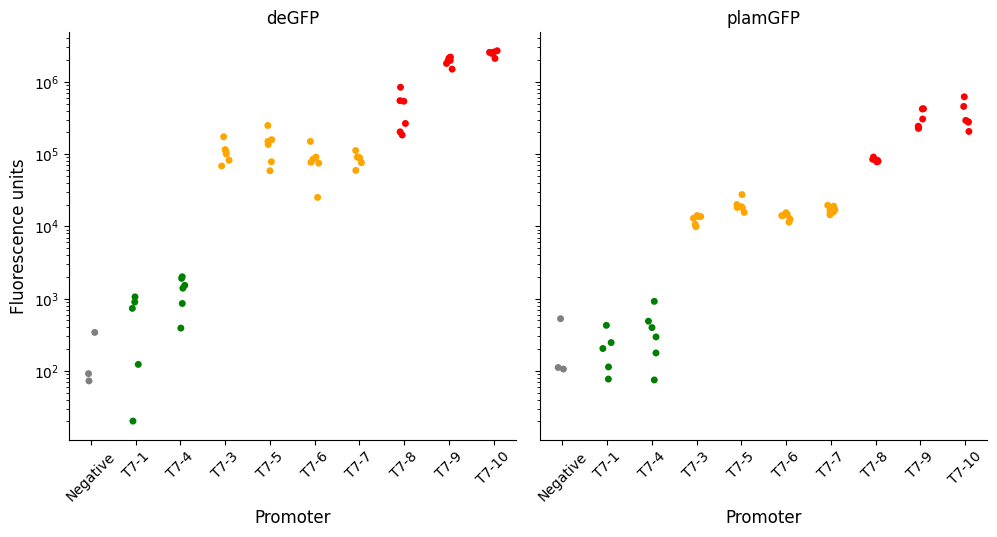

In [4]:

plot_order = [
    'Negative',
    'T7-1-deGFP', 
    'T7-4-deGFP',
    'T7-3-deGFP',
    'T7-5-deGFP',
    'T7-6-deGFP',
    'T7-7-deGFP',
    'T7-8-deGFP',
    'T7-9-deGFP',
    'T7-10-deGFP'
]

plot_order = [ re.sub(r"-deGFP", "", x) for x in plot_order ]

color_map = {
    'Negative': 'grey', 
    'T7-1': 'green',
    'T7-4': 'green',
    'T7-3': 'orange',
    'T7-5': 'orange',
    'T7-6': 'orange',
    'T7-7': 'orange',
    'T7-8': 'red',
    'T7-9': 'red',
    'T7-10': 'red'
}


fig = sns.catplot(
    data=data[data["Time"] > "06:00:00"].groupby(["PlateWell", "Protein", "Promoter", "Name"])["Blanked"].mean().reset_index(),
    x="Promoter",
    y="Blanked",
    col="Protein",
    palette=color_map,
    order=plot_order,
    # log_scale=True,
    kind="strip",
)

new_titles = ['deGFP', 'plamGFP'] 
for ax, title in zip(fig.axes.flat, new_titles):
    ax.set_title(title)

fig.set_ylabels("Fluorescence units", fontsize=12)
fig.set_xlabels("Promoter", fontsize=12)
fig.set_xticklabels(rotation=45, fontsize=10)
fig.set(yscale="log")
fig.savefig("../04-Figures/01-PURE_data/Summary_data.png", dpi=600)

# Plotting: low expression promoters

The low expression promoters are defined as T7-1 and T7-4. The data for these promoters is plotted for each experimentalist and reporter protein tested. 

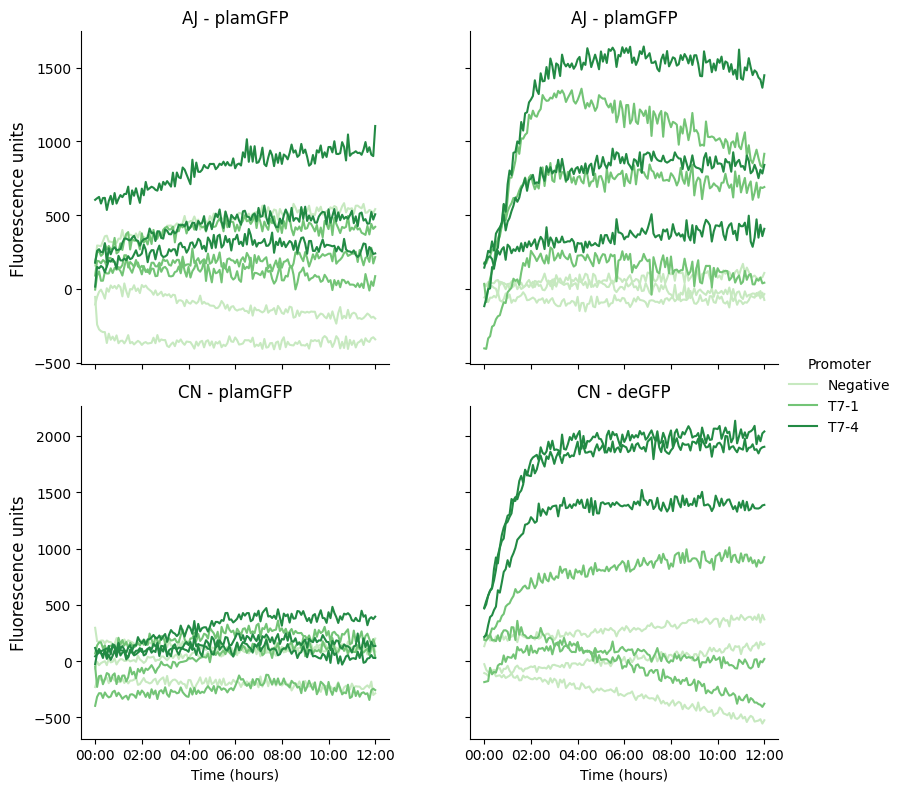

In [24]:
#| label: kinetics-low

Low_promoters = ["Negative", "T7-1", "T7-4"]
data[data["Name"].isin(Low_promoters)]

Low_promoters_plot=pr.plot_curves(data[data["Promoter"].isin(Low_promoters)], y="Blanked", units="PlateWell", col="Protein", row="Person", hue="Promoter", palette="Greens",estimator=None, height=4, facet_kws={"sharey":"row"})

Low_promoters_titles = ['AJ - plamGFP', 'AJ - plamGFP', 'CN - plamGFP', 'CN - deGFP'] 
for ax, title in zip(Low_promoters_plot.axes.flat, Low_promoters_titles):
    ax.set_title(title)
Low_promoters_plot.set_ylabels("Fluorescence units", fontsize=12);

# Plotting: mid expression promoters (plamGFP)

The mid expression promoters are defined as T7-3,T7-5,T7-6, and T7-7. The data for these promoters is plotted for each experimentalist testing the plamGFP reporter.

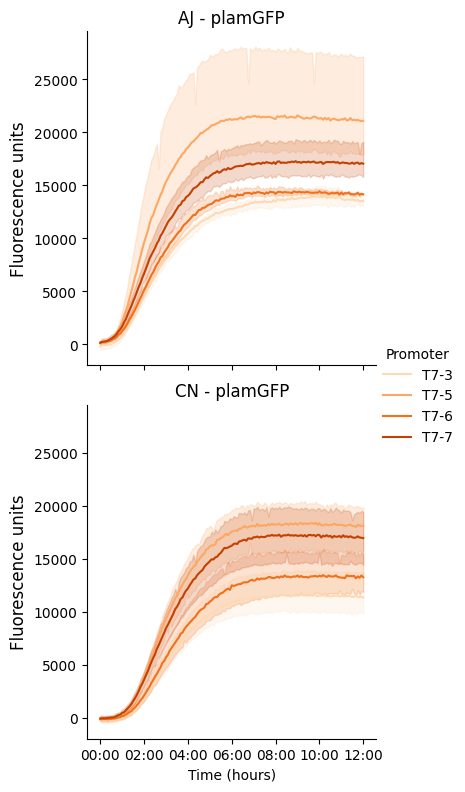

In [25]:
Mid_promoters_plamGFP = ["T7-3-plamGFP", "T7-5-plamGFP", "T7-6-plamGFP", "T7-7-plamGFP"]

Mid_promoters_plamGFP_plot=pr.plot_curves(data[data["Name"].isin(Mid_promoters_plamGFP)], y="Blanked", row="Person", hue="Promoter", palette="Oranges",height=4,)

Mid_promoters_plamGFP_titles = ['AJ - plamGFP', 'CN - plamGFP'] 
for ax, title in zip(Mid_promoters_plamGFP_plot.axes.flat, Mid_promoters_plamGFP_titles):
    ax.set_title(title)
Mid_promoters_plamGFP_plot.set_ylabels("Fluorescence units", fontsize=12)

# Plotting: mid expression promoters (deGFP)

The mid expression promoters are defined as T7-3,T7-5,T7-6, and T7-7. The data for these promoters is plotted for each experimentalist testing the deGFP reporter.

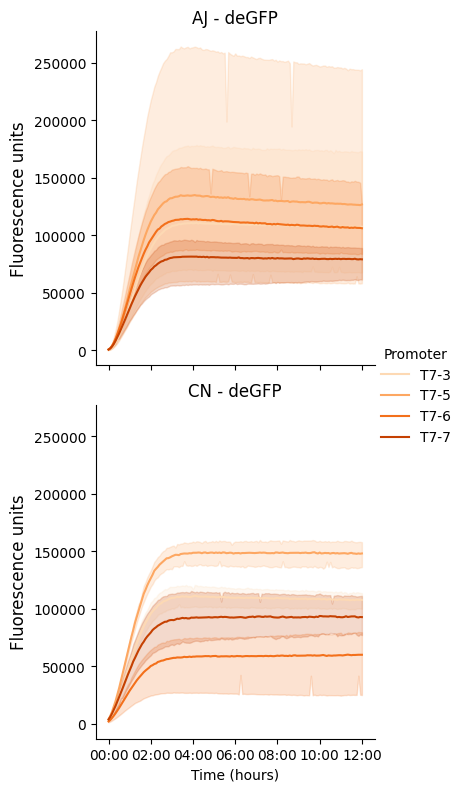

In [7]:
Mid_promoters_deGFP = ["T7-3-deGFP", "T7-5-deGFP", "T7-6-deGFP", "T7-7-deGFP"]

desired_row_order = ['AJ', 'CN']

Mid_promoters_deGFP_plot=pr.plot_curves(data[data["Name"].isin(Mid_promoters_deGFP)], y="Blanked", row="Person", row_order=desired_row_order, hue="Promoter", palette="Oranges",height=4,)

Mid_promoters_deGFP_titles = ['AJ - deGFP', 'CN - deGFP'] 
for ax, title in zip(Mid_promoters_deGFP_plot.axes.flat, Mid_promoters_deGFP_titles):
    ax.set_title(title)
Mid_promoters_deGFP_plot.set_ylabels("Fluorescence units", fontsize=12)

# Plotting: high expression promoters (plamGFP)

The high expression promoters are defined as T7-8,T7-9,T7-10. The data for these promoters is plotted for each experimentalist testing the plamGFP reporter.

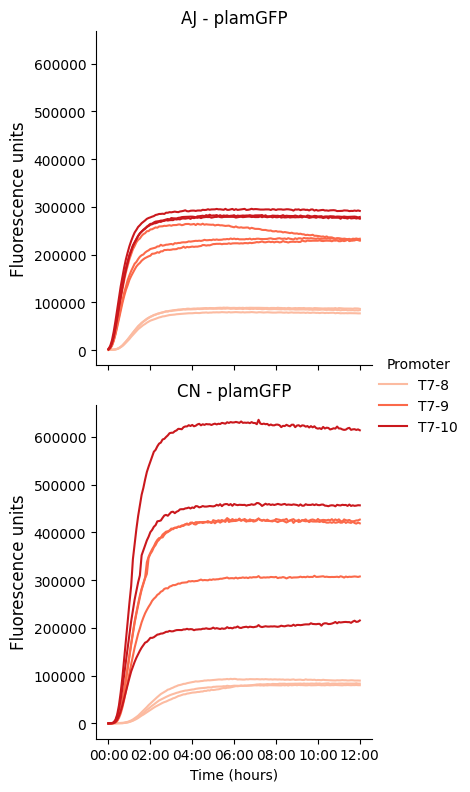

In [8]:
High_promoters_plamGFP = ["T7-8-plamGFP", "T7-9-plamGFP", "T7-10-plamGFP"]

High_promoters_plamGFP_plot=pr.plot_curves(data[data["Name"].isin(High_promoters_plamGFP)], units="PlateWell", y="Blanked", row="Person", hue="Promoter", palette="Reds", height=4, estimator=None)

High_promoters_plamGFP_titles = ['AJ - plamGFP', 'CN - plamGFP'] 
for ax, title in zip(High_promoters_plamGFP_plot.axes.flat, High_promoters_plamGFP_titles):
    ax.set_title(title)
High_promoters_plamGFP_plot.set_ylabels("Fluorescence units", fontsize=12)

# Plotting: high expression promoters (deGFP)

The high expression promoters are defined as T7-8,T7-9,T7-10. The data for these promoters is plotted for each experimentalist testing the deGFP reporter.

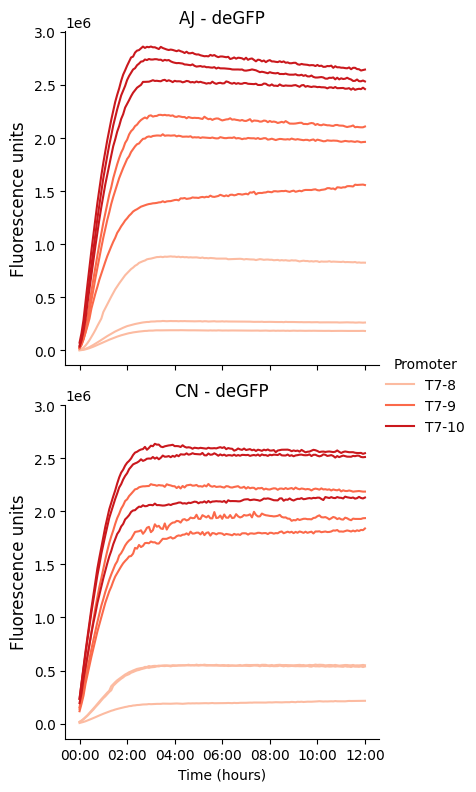

In [9]:
High_promoters_deGFP = ["T7-8-deGFP", "T7-9-deGFP", "T7-10-deGFP"]

High_promoters_deGFP_plot=pr.plot_curves(data[data["Name"].isin(High_promoters_deGFP)], units="PlateWell", y="Blanked", row="Person", row_order=desired_row_order, hue="Promoter", palette="Reds", height=4, estimator=None)

High_promoters_deGFP_titles = ['AJ - deGFP', 'CN - deGFP'] 
for ax, title in zip(High_promoters_deGFP_plot.axes.flat, High_promoters_deGFP_titles):
    ax.set_title(title)
High_promoters_deGFP_plot.set_ylabels("Fluorescence units", fontsize=12)

# Plotting: Mid/high expression promoters (combined plots)

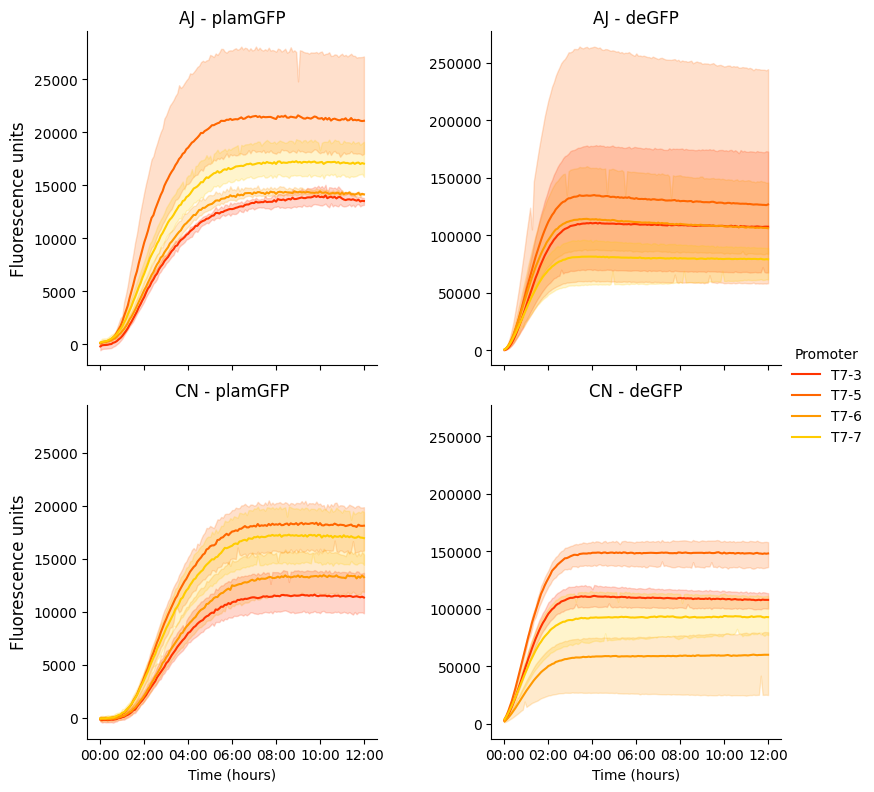

In [28]:
#| label: kinetics-medium

Mid_promoters = Mid_promoters_plamGFP + Mid_promoters_deGFP

desired_col_order = ['plamGFP', 'deGFP']

Mid_promoters_plot = pr.plot_curves(data[data["Name"].isin(Mid_promoters)],
    y="Blanked",
    row="Person",
    col="Protein",        
    col_order=desired_col_order,
    hue="Promoter",
    palette="autumn",
    height=4,
    facet_kws={'sharey': "col"},
)

Mid_promoters_titles = ['AJ - plamGFP', 'AJ - deGFP', 'CN - plamGFP', 'CN - deGFP']
for ax, title in zip(Mid_promoters_plot.axes.flat, Mid_promoters_titles):
    ax.set_title(title)
Mid_promoters_plot.set_ylabels("Fluorescence units", fontsize=12);
#Mid_promoters_plot.savefig("Mid_promoters_combined.png", dpi=600)

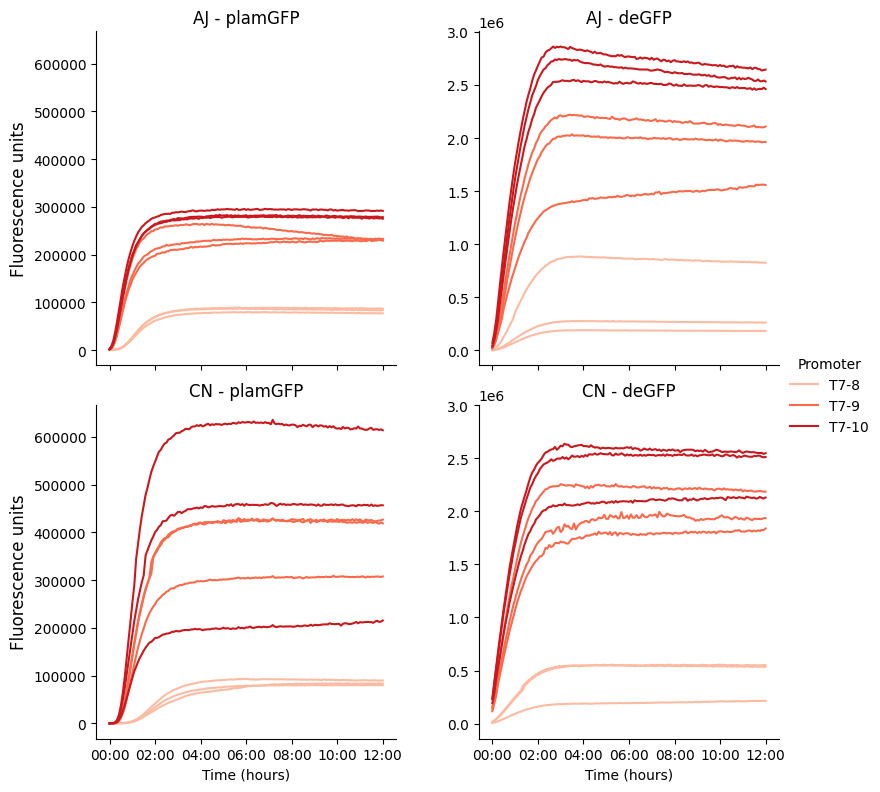

In [27]:
#| label: kinetics-high

High_promoters = High_promoters_plamGFP + High_promoters_deGFP

High_promoters_plot = pr.plot_curves(data[data["Name"].isin(High_promoters)],
    units="PlateWell",
    y="Blanked",
    row="Person",
    col="Protein",        
    col_order=desired_col_order,
    hue="Promoter",
    palette="Reds",
    height=4,
    facet_kws={'sharey': "col"},
    estimator=None
)

High_promoters_titles = ['AJ - plamGFP', 'AJ - deGFP', 'CN - plamGFP', 'CN - deGFP']
for ax, title in zip(High_promoters_plot.axes.flat, High_promoters_titles):
    ax.set_title(title)
High_promoters_plot.set_ylabels("Fluorescence units", fontsize=12);
#High_promoters_plot.savefig("High_promoters_combined.png", dpi=600)

# Plotting: Summary data plot (individual plotting)

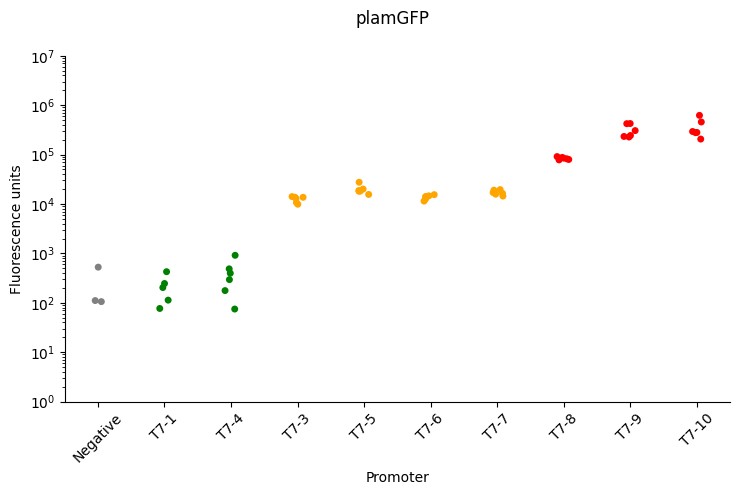

In [20]:
#| label: plamGFP-final-summary

plot_order = [
    'Negative',
    'T7-1-deGFP', 
    'T7-4-deGFP',
    'T7-3-deGFP',
    'T7-5-deGFP',
    'T7-6-deGFP',
    'T7-7-deGFP',
    'T7-8-deGFP',
    'T7-9-deGFP',
    'T7-10-deGFP'
]

plot_order = [ re.sub(r"-deGFP", "", x) for x in plot_order ]

color_map = {
    'Negative': 'grey', 
    'T7-1': 'green',
    'T7-4': 'green',
    'T7-3': 'orange',
    'T7-5': 'orange',
    'T7-6': 'orange',
    'T7-7': 'orange',
    'T7-8': 'red',
    'T7-9': 'red',
    'T7-10': 'red'
}
plot_data= data[data["Time"] > "06:00:00"].groupby(["PlateWell", "Protein", "Promoter", "Name"])["Blanked"].mean().reset_index()
#deGFP_plot= plot_data[plot_data["Protein"] == "deGFP"]
plamGFP_plot= plot_data[plot_data["Protein"] == "plamGFP"]


fig = sns.catplot(
    data=plamGFP_plot,
    x="Promoter",
    y="Blanked",
    palette=color_map,
    order=plot_order,
    kind="strip",
     height=5,              
    aspect=1.5    
)

fig.fig.suptitle("plamGFP", x=0.53)
fig.set_ylabels("Fluorescence units")
fig.set_xlabels("Promoter",)
fig.set_xticklabels(rotation=45,)
fig.set(yscale="log", ylim=(1, 10000000))

fig.tight_layout();
#fig.savefig("../04-Figures/01-PURE_data/Summary_data_deGFP.png", dpi=600)
#fig.savefig("../04-Figures/01-PURE_data/Summary_data_plamGFP.png", dpi=600)

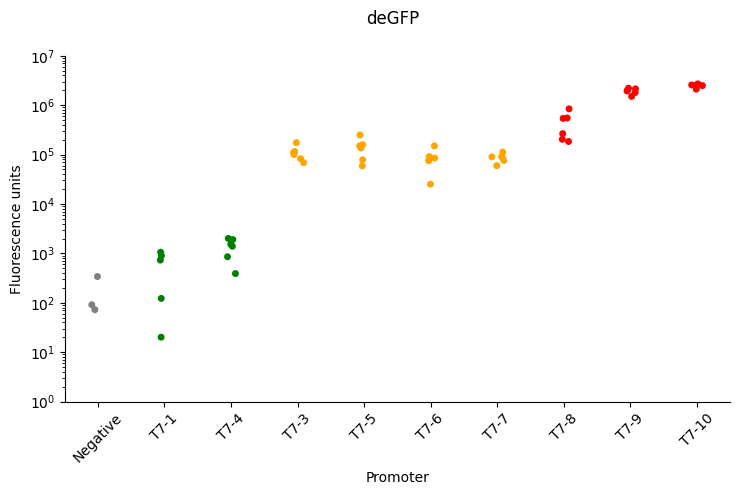

In [23]:
#| label: deGFP-final-summary

plot_order = [
    'Negative',
    'T7-1-deGFP', 
    'T7-4-deGFP',
    'T7-3-deGFP',
    'T7-5-deGFP',
    'T7-6-deGFP',
    'T7-7-deGFP',
    'T7-8-deGFP',
    'T7-9-deGFP',
    'T7-10-deGFP'
]

plot_order = [ re.sub(r"-deGFP", "", x) for x in plot_order ]

color_map = {
    'Negative': 'grey', 
    'T7-1': 'green',
    'T7-4': 'green',
    'T7-3': 'orange',
    'T7-5': 'orange',
    'T7-6': 'orange',
    'T7-7': 'orange',
    'T7-8': 'red',
    'T7-9': 'red',
    'T7-10': 'red'
}
plot_data= data[data["Time"] > "06:00:00"].groupby(["PlateWell", "Protein", "Promoter", "Name"])["Blanked"].mean().reset_index()
deGFP_plot= plot_data[plot_data["Protein"] == "deGFP"]
# plamGFP_plot= plot_data[plot_data["Protein"] == "plamGFP"]


fig = sns.catplot(
    data=deGFP_plot,
    x="Promoter",
    y="Blanked",
    palette=color_map,
    order=plot_order,
    kind="strip",
     height=5,              
    aspect=1.5    
)

fig.fig.suptitle("deGFP", x=0.53)
fig.set_ylabels("Fluorescence units")
fig.set_xlabels("Promoter",)
fig.set_xticklabels(rotation=45,)
fig.set(yscale="log", ylim=(1, 10000000))

fig.tight_layout();